In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern
import upsetplot
import warnings
def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [2]:
def load_evidence(fn, ds_name, metrics=False):
    # we only want derived since we're going to compare gene ids
    j = pd.read_json(fn)

    derived = j["derived"].apply(pd.Series).add_prefix("derived_")
    extracted = j["extracted"].apply(pd.Series).add_prefix("extracted_")
    source = j["source"].apply(pd.Series)#.add_prefix("source_")


    if metrics:
        source_metrics = source["source_metrics"].apply(pd.Series).add_prefix("source_metrics_")
        source = pd.concat([source, source_metrics], axis=1)
    # drop the original columns

    df = pd.concat([derived, extracted, source], axis=1)
    df["ds_name"] = ds_name

    # normalize the string values for cell types
    df["extracted_cell_type_label"] = df["extracted_cell_type_label"].str.strip().str.upper()
    # df["extracted_cell_type_id"] = df["extracted_cell_type_id"].str.strip().str.upper()

    df["derived_cell_type_label"] = df["derived_cell_type_label"].str.strip().str.upper()
    df["derived_cell_type_id"] = df["derived_cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    df["extracted_feature_name"] = df["extracted_feature_name"].str.strip().str.upper()
    df["derived_feature_name"] = df["derived_feature_name"].str.strip().str.upper()

    # df["extracted_feature_identifier"] = df["extracted_feature_identifier"].str.strip().str.upper()
    df["derived_feature_identifier"] = df["derived_feature_identifier"].str.strip().str.upper()


    return df

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [90]:
# ds = "adipose_Hildreth2021"
# ds = "adipose_Vijay2019"
# ds = "bone_He2021"
# ds_deg = "heart_Tucker2020"
# ds_hmn = "heart_Tucker2020"

# ds_deg = "bladder_Yu2019"
# ds_hmn = "bladder_Yu2019"

# ds_deg = "adipose_Emont2022"
# ds_hmn = "adipose_Emont2022"

ds_deg = "adipose_Hildreth2021"
ds_hmn = "adipose_Hildreth2021"
ds_llm = "adipose_Hildreth2021"

ds = ["adipose_Hildreth2021", "bone_He2021", "heart_Tucker2020", "bladder_Yu2019", "adipose_Emont2022"]

data = []

for ds_hmn, ds_deg in zip(ds, ds):
    fn_hmn   = f"../../data/{ds_hmn}/evidence_human/evidence.json"
    fn_deg   = f"../../data/{ds_deg}/evidence_deg/evidence_unfiltered_metrics.json"
    # fn_llm   = f"../../data/{ds_llm}/evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22/evidence.json"

    hmn = load_evidence(fn_hmn, ds_hmn)
    deg = load_evidence(fn_deg, ds_deg, metrics=True)
    # llm = load_evidence(fn_llm, ds_llm)

    # drop everything ecept for the derived and source columns
    hmn = hmn.loc[:, hmn.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"])
    
    deg = deg.loc[:, deg.columns.str.contains("derived_|source_")].rename(columns=lambda x: x.replace("derived_", "")).dropna(subset=["feature_identifier"]).drop(columns=["source_metrics"]).rename(columns=lambda x: x.replace("source_metrics_", ""))


    img = hmn.query("source_type == 'image'")
    txt = hmn.query("source_type == 'text'")


    celltypes = np.union1d(hmn["cell_type_id"].unique(), deg["cell_type_id"].unique())
    data.append({"ds_name": ds_hmn, "deg": deg, "img": img, "txt": txt, "celltypes": celltypes})

In [4]:
txt = data[0]["txt"].copy()
img = data[0]["img"].copy()
deg = data[0]["deg"].copy()

In [24]:
feature = "feature_identifier"

txt_features = pd.Series(txt[feature].unique()).dropna().tolist()
img_features = pd.Series(img[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

genes = {
    "txt": txt_features,
    "img": img_features,
    "deg": deg_features,
}


feature = "cell_type_id"

txt_features = pd.Series(txt[feature].unique()).dropna().tolist()
img_features = pd.Series(img[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

celltypes = {
    "txt": txt_features,
    "img": img_features,
    "deg": deg_features,
}


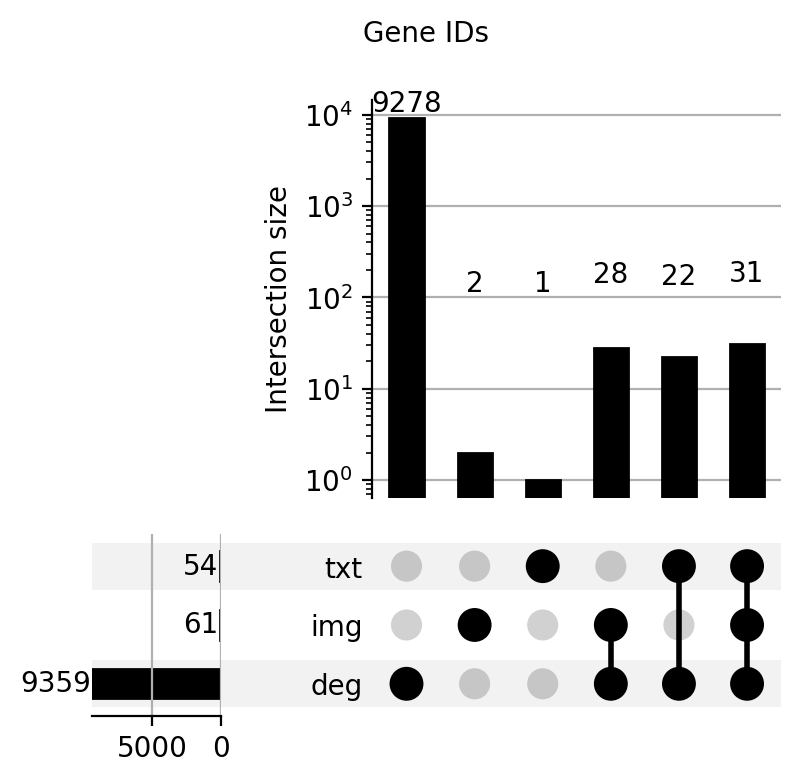

In [30]:
fig = plt.figure(figsize=(10, 6))


ud = upsetplot.from_contents(genes)
up = upsetplot.plot(ud, show_counts=True,fig=fig)

for ax in fig.axes:
    if ax.get_ylabel() == 'Intersection size':  # vertical bar plot
        ax.set_yscale('log')


fig.suptitle("Gene IDs", fontsize=fsize)


plt.tight_layout()
plt.show()

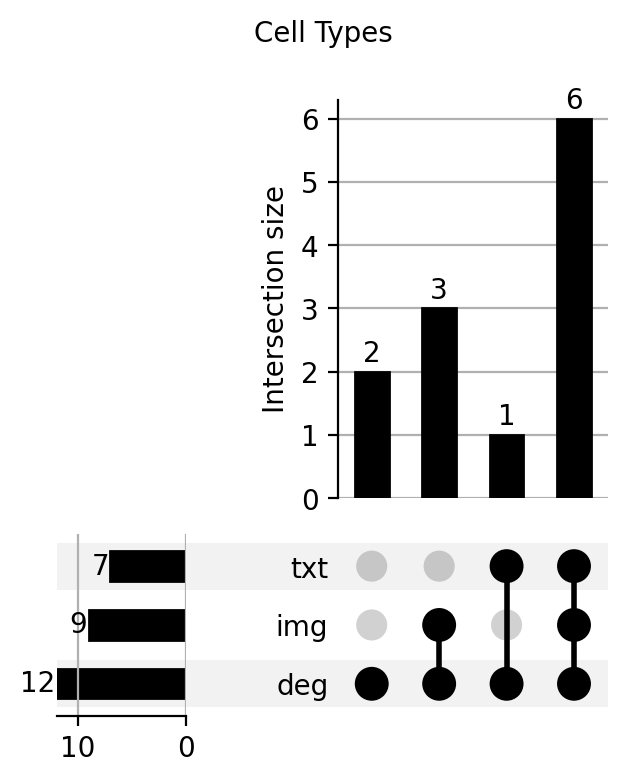

In [29]:
fig = plt.figure(figsize=(10, 6))


ud = upsetplot.from_contents(celltypes)
up = upsetplot.plot(ud, show_counts=True,fig=fig)
fig.suptitle("Cell Types", fontsize=fsize)

plt.tight_layout()
plt.show()

# DEG, IMG, TXT, comparisons


In [32]:
import matplotlib.patches as patches


def hatch_cell(ax, i, j, hatch='//', color='white'):
    rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                             linewidth=0, edgecolor='black', facecolor=color,
                             hatch=hatch, zorder=2, alpha=0.8)
    ax.add_patch(rect)



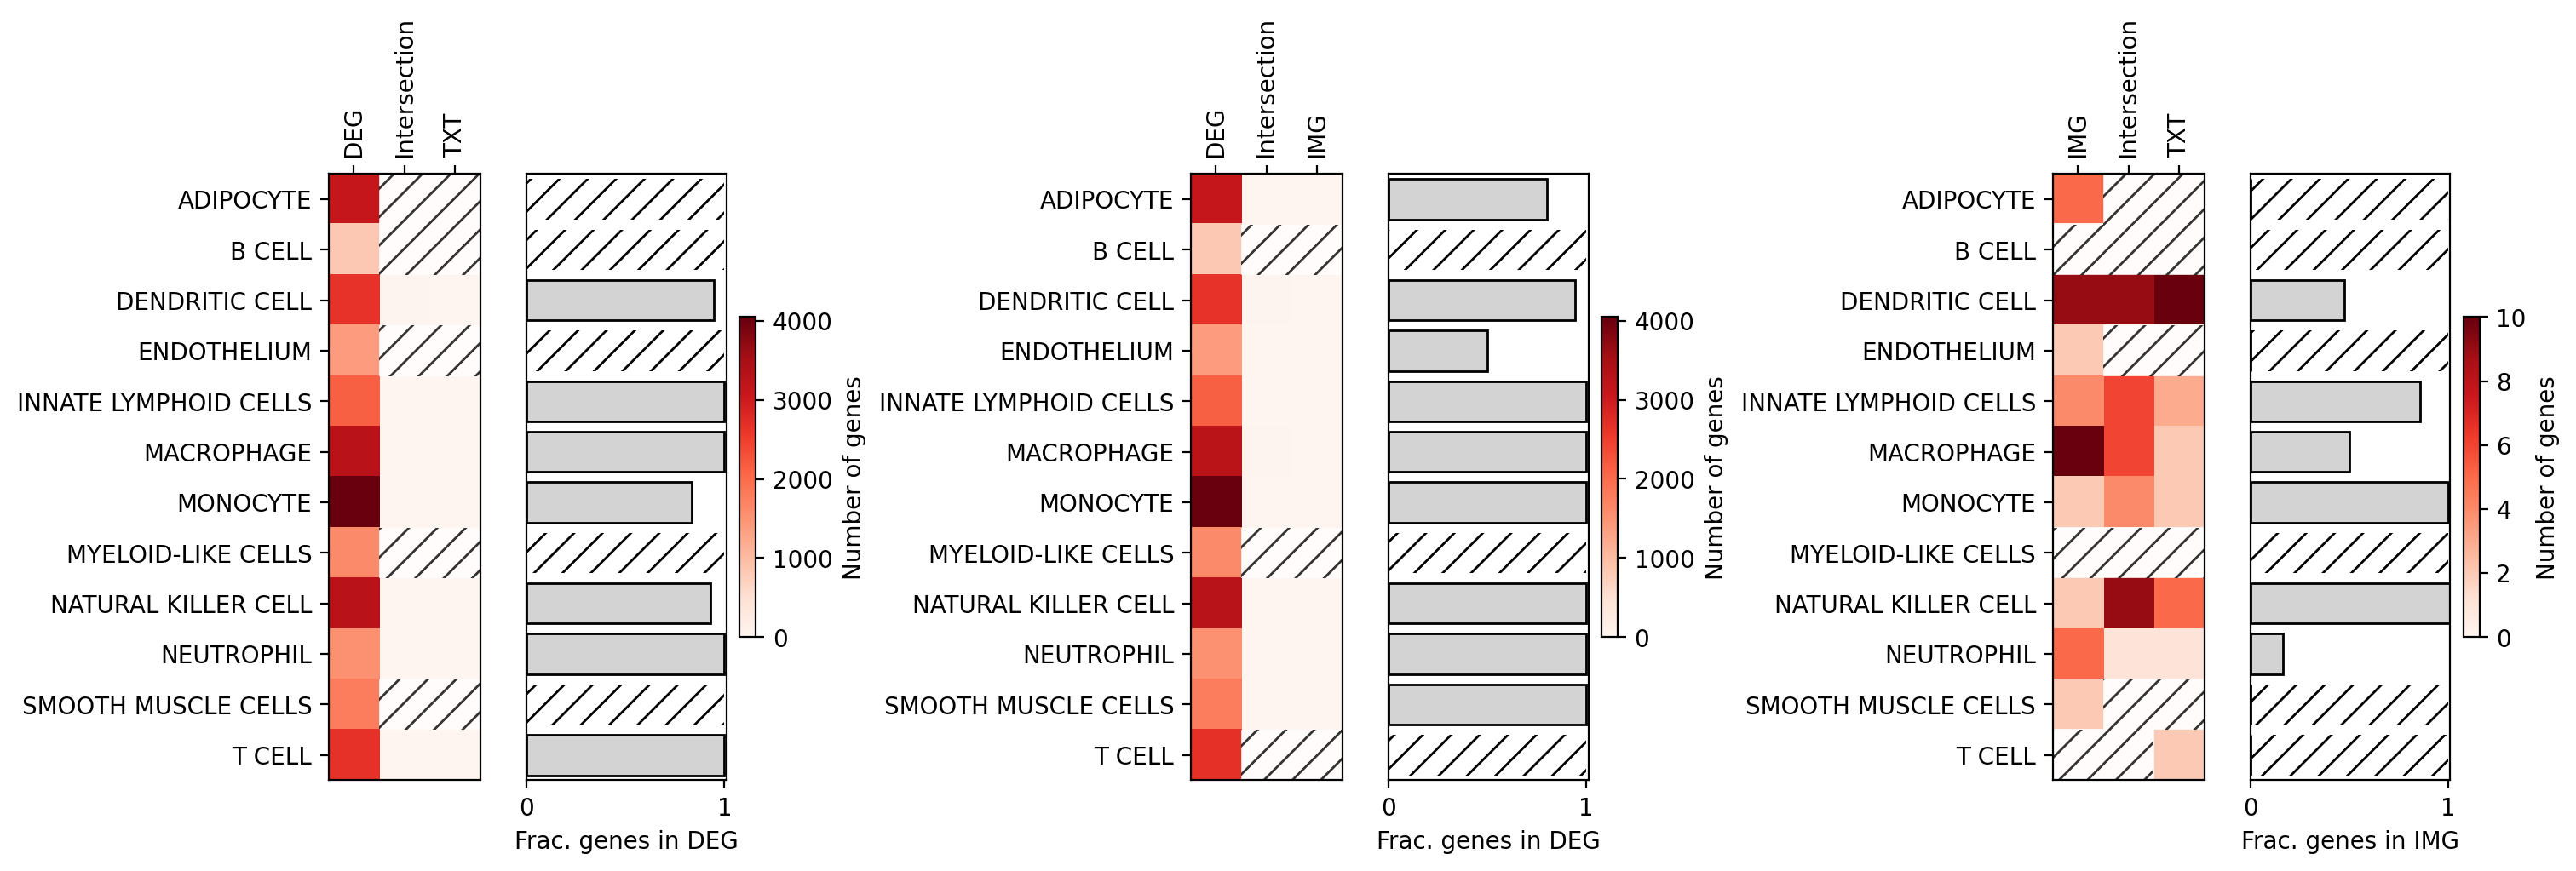

In [204]:
cmps = [
    ("deg", "txt"),
    ("deg", "img"),
    ("img", "txt"),
    # ("img", "txt"),
]
fig, axs = plt.subplots(figsize=(15,5), ncols=6, constrained_layout=True)

for idx, (a, b) in enumerate(cmps):

    t1 = data[0][a].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(data[0]["celltypes"], fill_value=[])
    t2 = data[0][b].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(data[0]["celltypes"], fill_value=[])

    l = t1.combine(t2, lambda a, b: np.setdiff1d(a, b).shape[0]).rename(f"{a}")
    x = t1.combine(t2, lambda a, b: np.intersect1d(a, b).shape[0]).rename("x")
    r = t1.combine(t2, lambda a, b: np.setdiff1d(b, a).shape[0]).rename(f"{b}")
    mtx = pd.concat([l,x,r], axis=1)


    ax = axs[2*idx]
    xlabels = [f"{a.upper()}", "Intersection", f"{b.upper()}"]
    eye = mtx.values

    cax = ax.imshow(eye, cmap="Reds")#, vmin=0, vmax=1)

    not_in_t1 = np.where(t1.apply(lambda x: len(x)) == 0)[0]
    not_in_t2 = np.where(t2.apply(lambda x: len(x)) == 0)[0]

    # Apply hatch to specific cells
    for i in not_in_t1:
        hatch_cell(ax, i, 0)

    for i in not_in_t2:
        hatch_cell(ax, i, 2)

    for i in np.unique(np.concatenate([not_in_t1, not_in_t2])):
        hatch_cell(ax, i, 1)


    ax.set(**{
        "xticks": np.arange(len(xlabels)),
        "yticks": np.arange(len(data[0]["celltypes"])),
        "xticklabels": xlabels,
        "yticklabels": data[0]["celltypes"],
    })
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')  # Set the label position at the top

    ax = axs[2*idx+1]
    if a == "deg":
        xlabel = "Frac. genes in DEG"
        jac = eye[:,1] / (eye[:,2] + eye[:,1])
    elif idx == 2:
        xlabel = "Frac. genes in IMG"
        jac = eye[:,1] / (eye[:,2] + eye[:,0])
    else:
        xlabel = "Jaccard Similarity"
        jac = eye[:,1] / (eye[:,1] + eye[:,2] + eye[:,0])
    jac = jac[::-1]

    ax.barh(np.arange(len(data[0]["celltypes"])), jac, edgecolor="black", facecolor="lightgrey")

    highlight_indices = np.unique(np.concatenate([not_in_t1, not_in_t2]))

    # Overlay bars with hatch patterns for highlighted indices
    for i in highlight_indices:
        ax.barh(len(data[0]["celltypes"])-i-1, 1, edgecolor="black",
                facecolor="none", hatch='//', linewidth=0)
        
    ax.set(**{
        "yticks": np.arange(len(data[0]["celltypes"])),
        "yticklabels": [],
        "xlabel": xlabel,
        "xlim": (0,1.01),
        "ylim": (-0.5, len(data[0]["celltypes"])-0.5)
    })
    ax.yaxis.set_visible(False)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
    plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Number of genes")


In [129]:
t1 = data[0]["txt"].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(data[0]["celltypes"], fill_value=[])
t2 = data[0]["deg"].groupby(["cell_type_id"])["feature_identifier"].apply(list).reindex(data[0]["celltypes"], fill_value=[])

t1.combine(t2, lambda a, b: np.setdiff1d(a, b)).rename("txt")

cell_type_id
ADIPOCYTE                               []
B CELL                                  []
DENDRITIC CELL           [ENSG00000170458]
ENDOTHELIUM                             []
INNATE LYMPHOID CELLS                   []
MACROPHAGE                              []
MONOCYTE                 [ENSG00000188404]
MYELOID-LIKE CELLS                      []
NATURAL KILLER CELL      [ENSG00000162747]
NEUTROPHIL                              []
SMOOTH MUSCLE CELLS                     []
T CELL                                  []
Name: txt, dtype: object

In [131]:
ft = "ENSG00000188404"
ct = "MONOCYTE"


print(data[0]["txt"].query(f"feature_identifier == '{ft}' & cell_type_id == '{ct}'").iloc[0].source_rationale)
print(data[0]["txt"].query(f"feature_identifier == '{ft}' & cell_type_id == '{ct}'").iloc[0].feature_name)

 Our analysis identified three populations of monocytes: ncMos based on expression of FCGR3A and HES4, Mo-1s by expression of FCER1A and Mo-2s via increased expression of CSF3R, FCAR and SELL, compared with Mo-1s (Fig. 4b and Extended Data Fig. 6b-d).
SELL


In [132]:
data[0]["txt"].query(f"feature_identifier == '{ft}'")

,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,source_type,source_rationale,source_id
10,homo_sapiens,NATURAL KILLER CELL,NK-LIKE (NATURAL KILLER LIKE) CELLS,adipose,none,SELL,gene,ENSG00000188404,ensembl,text,"However, we also identified the presence of t...",text
23,homo_sapiens,INNATE LYMPHOID CELLS,WAT ILC (WHITE ADIPOSE TISSUE INNATE LYMPHOID ...,adipose,none,SELL,gene,ENSG00000188404,ensembl,text,WAT ILC clusters were defined based on differ...,text
25,homo_sapiens,NATURAL KILLER CELL,MNK (MATURE NATURAL KILLER) CELLS,adipose,none,CD62L,gene,ENSG00000188404,ensembl,text,Flow cytometry experiments corroborated the r...,text
31,homo_sapiens,INNATE LYMPHOID CELLS,ILCPS (INNATE LYMPHOID PRECURSOR CELLS),adipose,none,CD62L,gene,ENSG00000188404,ensembl,text,results obtained with CD200R1+CD62L+ ILCPs de...,text
37,homo_sapiens,MONOCYTE,MO-2S (MONOCYTE 2),adipose,none,SELL,gene,ENSG00000188404,ensembl,text,Our analysis identified three populations of ...,text


In [133]:
data[0]["deg"].query(f"cell_type_id == '{ct}' & feature_identifier == '{ft}'")

,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,source_type,source_rationale,source_id,p_corr,log_fc


In [118]:
txt_idx = data[0]["txt"].set_index(["cell_type_id", "feature_identifier"]).index
img_idx = data[0]["img"].set_index(["cell_type_id", "feature_identifier"]).index
deg_idx = data[0]["deg"].set_index(["cell_type_id", "feature_identifier"]).index

comm_img = deg_idx.intersection(img_idx)
comm_txt = deg_idx.intersection(txt_idx)
setd_img = deg_idx.difference(img_idx)
setd_txt = deg_idx.difference(txt_idx)


d_img = (data[0]["deg"]
         .set_index(["cell_type_id", "feature_identifier"])
         .loc[comm_img]
         .reset_index())
ct_img = d_img["cell_type_id"].unique()

avg_gene_per_ct = d_img.groupby("cell_type_id")["feature_identifier"].apply(lambda x: len(x.unique())).mean()

n_img = (data[0]["deg"]
         .set_index(["cell_type_id", "feature_identifier"])
         .loc[setd_img]
         .reset_index()
         .query("p_corr < 0.01")
         .groupby("cell_type_id")
         .apply(lambda x: x.nlargest(int(avg_gene_per_ct*1.10), "log_fc"))
         .loc[ct_img]
         .reset_index(drop=True))


d_txt = (data[0]["deg"]
         .set_index(["cell_type_id", "feature_identifier"])
         .loc[comm_txt]
         .reset_index())
ct_txt = d_txt["cell_type_id"].unique()
avg_gene_per_ct = d_txt.groupby("cell_type_id")["feature_identifier"].apply(lambda x: len(x.unique())).mean()

n_txt = (data[0]["deg"]
         .set_index(["cell_type_id", "feature_identifier"])
         .loc[setd_txt]
         .reset_index()
         .query("p_corr < 0.01")
         .groupby("cell_type_id")
         .apply(lambda x: x.nlargest(int(avg_gene_per_ct*1.10), "log_fc"))
         .loc[ct_txt]
         .reset_index(drop=True)
)

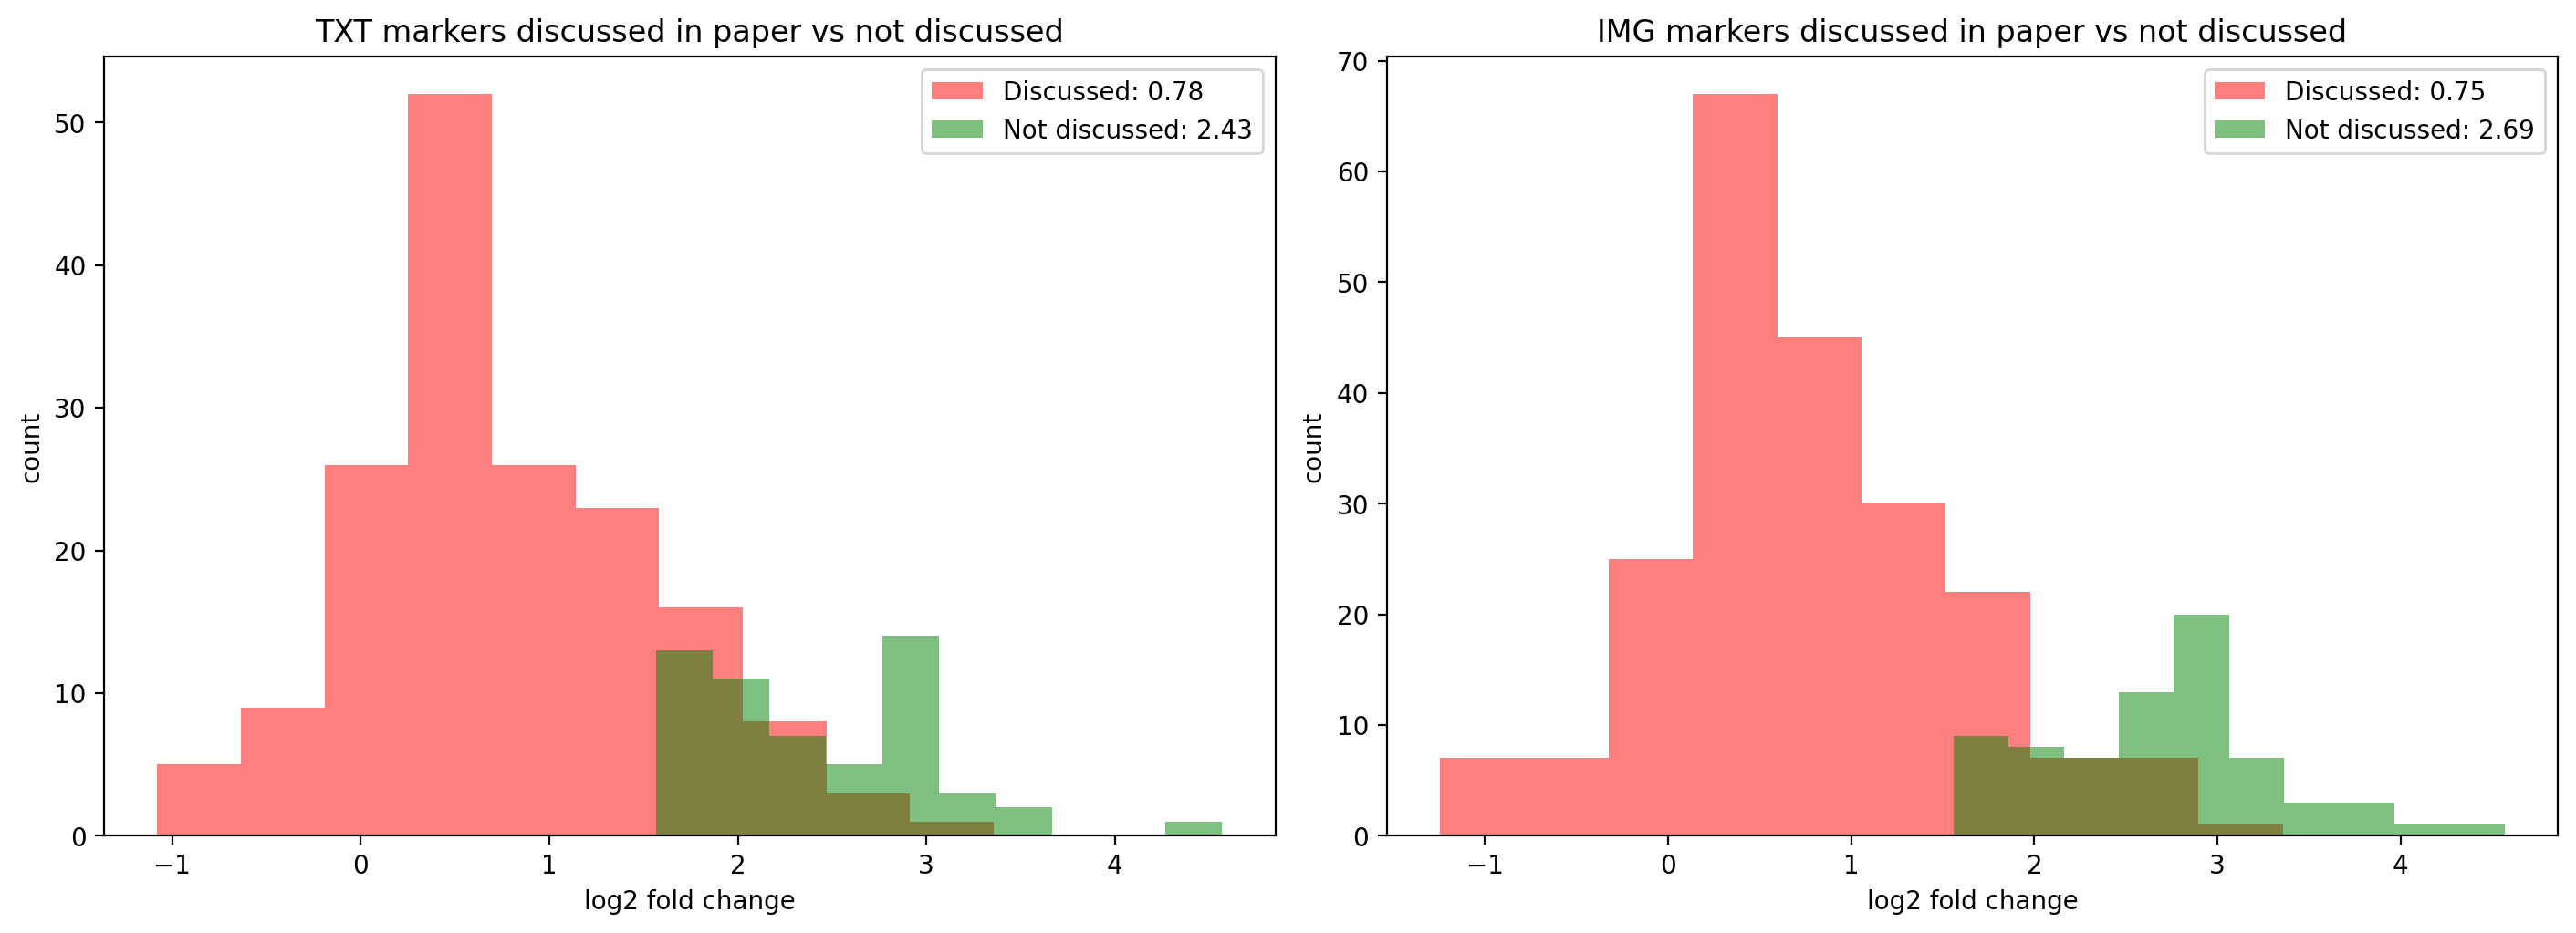

In [203]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=2, constrained_layout=True)

ax = axs[0]
x = d_txt["log_fc"]
mean = np.mean(x)
ax.hist(x, alpha=0.5, color="red", label=f"Discussed: {mean:.2f}")


x = n_txt["log_fc"]

mean = np.mean(x)
ax.hist(x, alpha=0.5, color="green", label=f"Not discussed: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",
    "title": "TXT markers discussed in paper vs not discussed",

})
ax.legend()

ax = axs[1]
x = d_img["log_fc"]
mean = np.mean(x)
ax.hist(x, alpha=0.5, color="red", label=f"Discussed: {mean:.2f}")


x = n_img["log_fc"]

mean = np.mean(x)
ax.hist(x, alpha=0.5, color="green", label=f"Not discussed: {mean:.2f}")

ax.set(**{
    "xlabel": "log2 fold change",
    "ylabel": "count",
    "title": "IMG markers discussed in paper vs not discussed",

})
ax.legend()
plt.show()

In [134]:
gb_d_txt = d_txt.groupby("cell_type_id").agg({"log_fc": "mean", "p_corr": "mean"}).reindex(data[0]["celltypes"], fill_value=pd.NA)
gb_n_txt = n_txt.groupby("cell_type_id").agg({"log_fc": "mean",
 "p_corr": "mean"}).reindex(data[0]["celltypes"], fill_value=pd.NA)

v_d_txt = d_txt.groupby("cell_type_id")["log_fc"].apply(list).reindex(data[0]["celltypes"], fill_value=[])
v_n_txt = n_txt.groupby("cell_type_id")["log_fc"].apply(list).reindex(data[0]["celltypes"], fill_value=[])

gb_d_img = d_img.groupby("cell_type_id").agg({"log_fc": "mean", "p_corr": "mean"}).reindex(data[0]["celltypes"], fill_value=pd.NA)
gb_n_img = n_img.groupby("cell_type_id").agg({"log_fc": "mean",
 "p_corr": "mean"}).reindex(data[0]["celltypes"], fill_value=pd.NA)

v_d_img = d_img.groupby("cell_type_id")["log_fc"].apply(list).reindex(data[0]["celltypes"], fill_value=[])
v_n_img = n_img.groupby("cell_type_id")["log_fc"].apply(list).reindex(data[0]["celltypes"], fill_value=[])



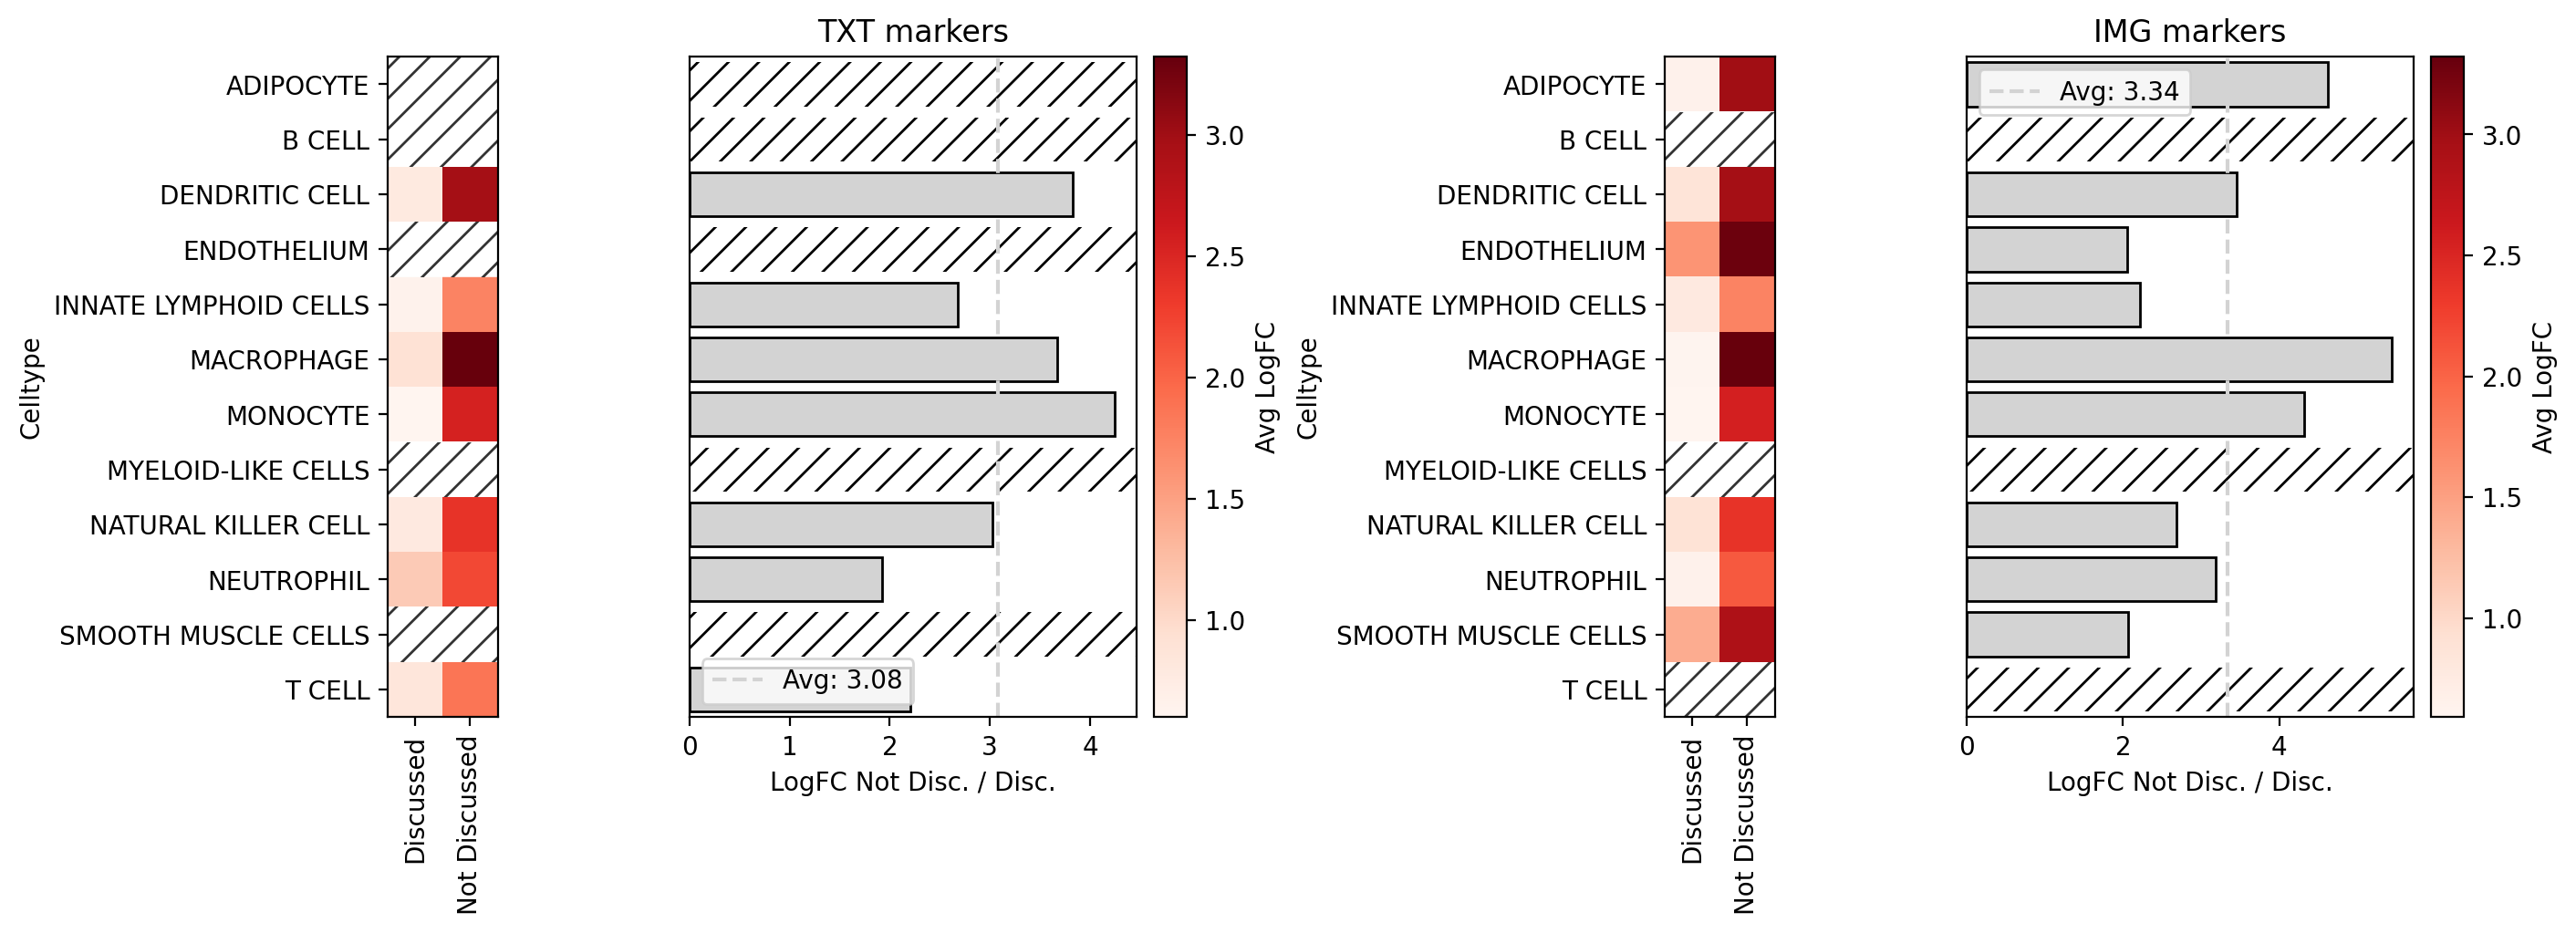

In [196]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=4, constrained_layout=True)
fig.subplots_adjust(hspace=0, wspace=0)

########################################### TEXT
ax = axs[0]
x = gb_d_txt["log_fc"].values
y = gb_n_txt["log_fc"].values
lfc_data = np.stack([x, y]).T

cax = ax.imshow(lfc_data, cmap="Reds")
ax.set(**{
    # "title": f"Avg. LogFC",
    "ylabel": f"Celltype",
    "xticks": [0,1],
    "xticklabels": ["Discussed", "Not Discussed"],
    "yticks": np.arange(len(x)),
    "yticklabels": data[0]["celltypes"]
})
ax.set_yticklabels(ax.get_yticklabels(), ha='right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')

not_in_t1 = np.where(np.isnan(x))[0]
not_in_t2 = np.where(np.isnan(y))[0]

# Apply hatch to specific cells
for i in not_in_t1:
    hatch_cell(ax, i, 0)

for i in not_in_t2:
    hatch_cell(ax, i, 1)

ax = axs[1]
ratio = lfc_data[:,1] / lfc_data[:,0]

ax.barh(np.arange(len(x)), ratio[::-1], edgecolor="black", facecolor="lightgrey")
meanr = ratio[~np.isnan(ratio)].mean()

highlight_indices = np.unique(np.concatenate([not_in_t1, not_in_t2]))

# Overlay bars with hatch patterns for highlighted indices
for i in highlight_indices:
    ax.barh(len(data[0]["celltypes"])-i-1, ratio[~np.isnan(ratio)].max()*1.05, edgecolor="black",
            facecolor="none", hatch='//', linewidth=0)

ax.axvline(x=meanr, color="lightgrey", linestyle="--", label=f"Avg: {meanr:,.2f}")
ax.set(**{
    "yticks": np.arange(len(x)),
    "yticklabels": [],
    "xlabel": "LogFC Not Disc. / Disc.",
    "ylim": (-0.5, len(x)-0.5),
    "xlim": (0,ratio[~np.isnan(ratio)].max()*1.05),
    "title": "TXT markers"
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Avg LogFC")
ax.legend()

################################################################### IMAGE
ax = axs[2]
x = gb_d_img["log_fc"].values
y = gb_n_img["log_fc"].values
lfc_data = np.stack([x, y]).T

cax = ax.imshow(lfc_data, cmap="Reds")
ax.set(**{
    # "title": f"Avg. LogFC",
    "ylabel": f"Celltype",
    "xticks": [0,1],
    "xticklabels": ["Discussed", "Not Discussed"],
    "yticks": np.arange(len(x)),
    "yticklabels": data[0]["celltypes"],
})
ax.set_yticklabels(ax.get_yticklabels(), ha='right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')

not_in_t1 = np.where(np.isnan(x))[0]
not_in_t2 = np.where(np.isnan(y))[0]

# Apply hatch to specific cells
for i in not_in_t1:
    hatch_cell(ax, i, 0)

for i in not_in_t2:
    hatch_cell(ax, i, 1)

ax = axs[3]
ratio = lfc_data[:,1] / lfc_data[:,0]

ax.barh(np.arange(len(x)), ratio[::-1], edgecolor="black", facecolor="lightgrey")
meanr = ratio[~np.isnan(ratio)].mean()

highlight_indices = np.unique(np.concatenate([not_in_t1, not_in_t2]))

# Overlay bars with hatch patterns for highlighted indices
for i in highlight_indices:
    ax.barh(len(data[0]["celltypes"])-i-1, ratio[~np.isnan(ratio)].max()*1.05, edgecolor="black",
            facecolor="none", hatch='//', linewidth=0)

ax.axvline(x=meanr, color="lightgrey", linestyle="--", label=f"Avg: {meanr:,.2f}")
ax.set(**{
    "yticks": np.arange(len(x)),
    "yticklabels": [],
    "xlabel": "LogFC Not Disc. / Disc.",
    "ylim": (-0.5, len(x)-0.5),
    "xlim": (0,ratio[~np.isnan(ratio)].max()*1.05),
    "title": "IMG markers"
})
ax.yaxis.set_visible(False)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, horizontalalignment='right')
plt.colorbar(cax, ax=ax, fraction=0.08, pad=0.04, label="Avg LogFC")
ax.legend()
plt.show()


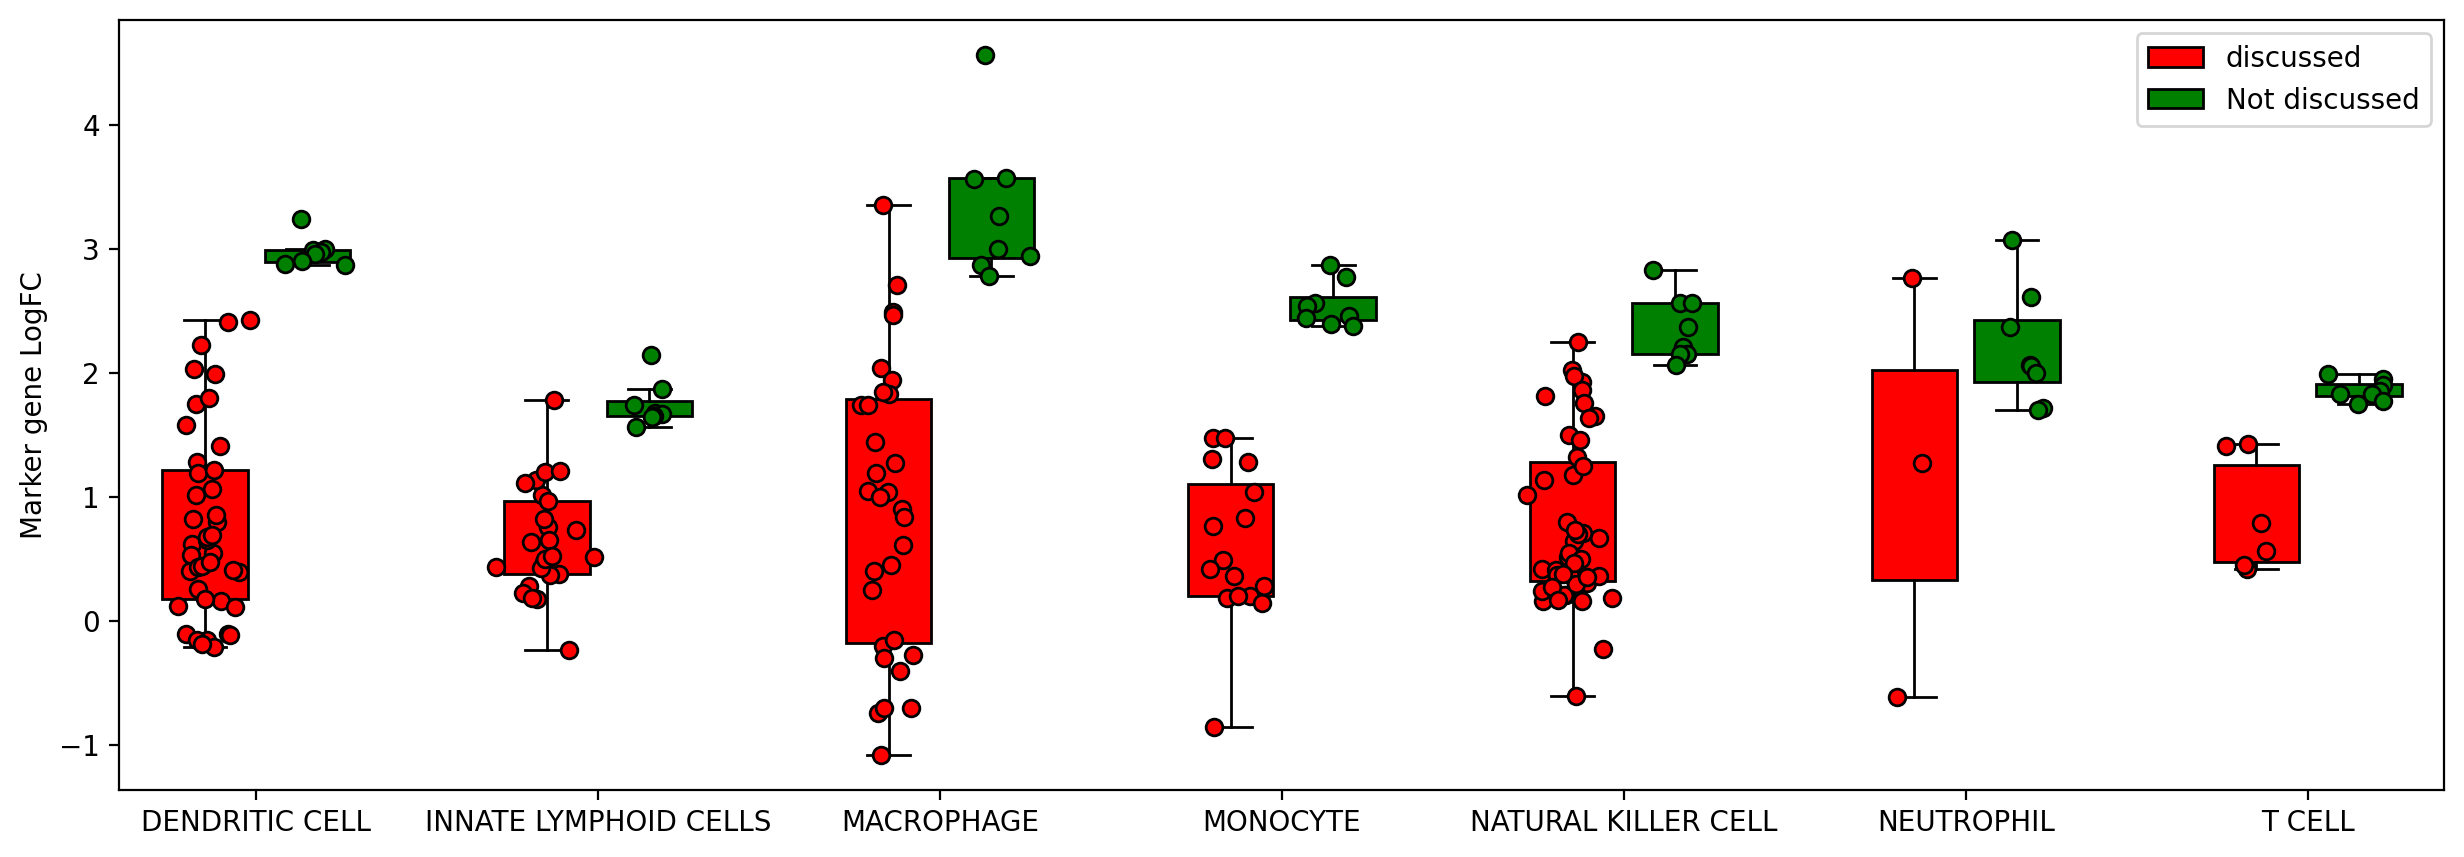

In [192]:
fig, ax = plt.subplots(figsize=(15, 5))

dist_bw = 2
space = 0.3

# Data preparation
labels = v_d_txt[v_d_txt.apply(lambda x: len(x)>0)].index
x = v_d_txt[v_d_txt.apply(lambda x: len(x)>0)].values
y = v_n_txt[v_n_txt.apply(lambda x: len(x)>0)].values

idx = np.arange(len(labels)) * dist_bw

# Boxplots
ax.boxplot(x, positions=idx - space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='red'), label="discussed", showfliers=False)
ax.boxplot(y, positions=idx + space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='green'), label="Not discussed", showfliers=False)

for i, xx, yy in zip(idx, x, y):
    xxx = np.random.normal(i-space, 0.1, size=len(xx))
    yyy = np.random.normal(i+space, 0.1, size=len(yy))
    ax.scatter(xxx, xx, edgecolor="k", facecolor="red", zorder=10)
    ax.scatter(yyy, yy, edgecolor="k", facecolor="green", zorder=10)


# Formatting
ax.set(**{
    "xticks": np.arange(len(labels)) * dist_bw,
    "xticklabels": labels,
    "ylabel": "Marker gene LogFC"
})
# for v in  np.arange(len(labels)) * dist_bw + dist_bw/2:
#     ax.axvline(v, color="lightgrey")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=10)

# ax.set_ylim(bottom=0)

ax.legend()
plt.show()

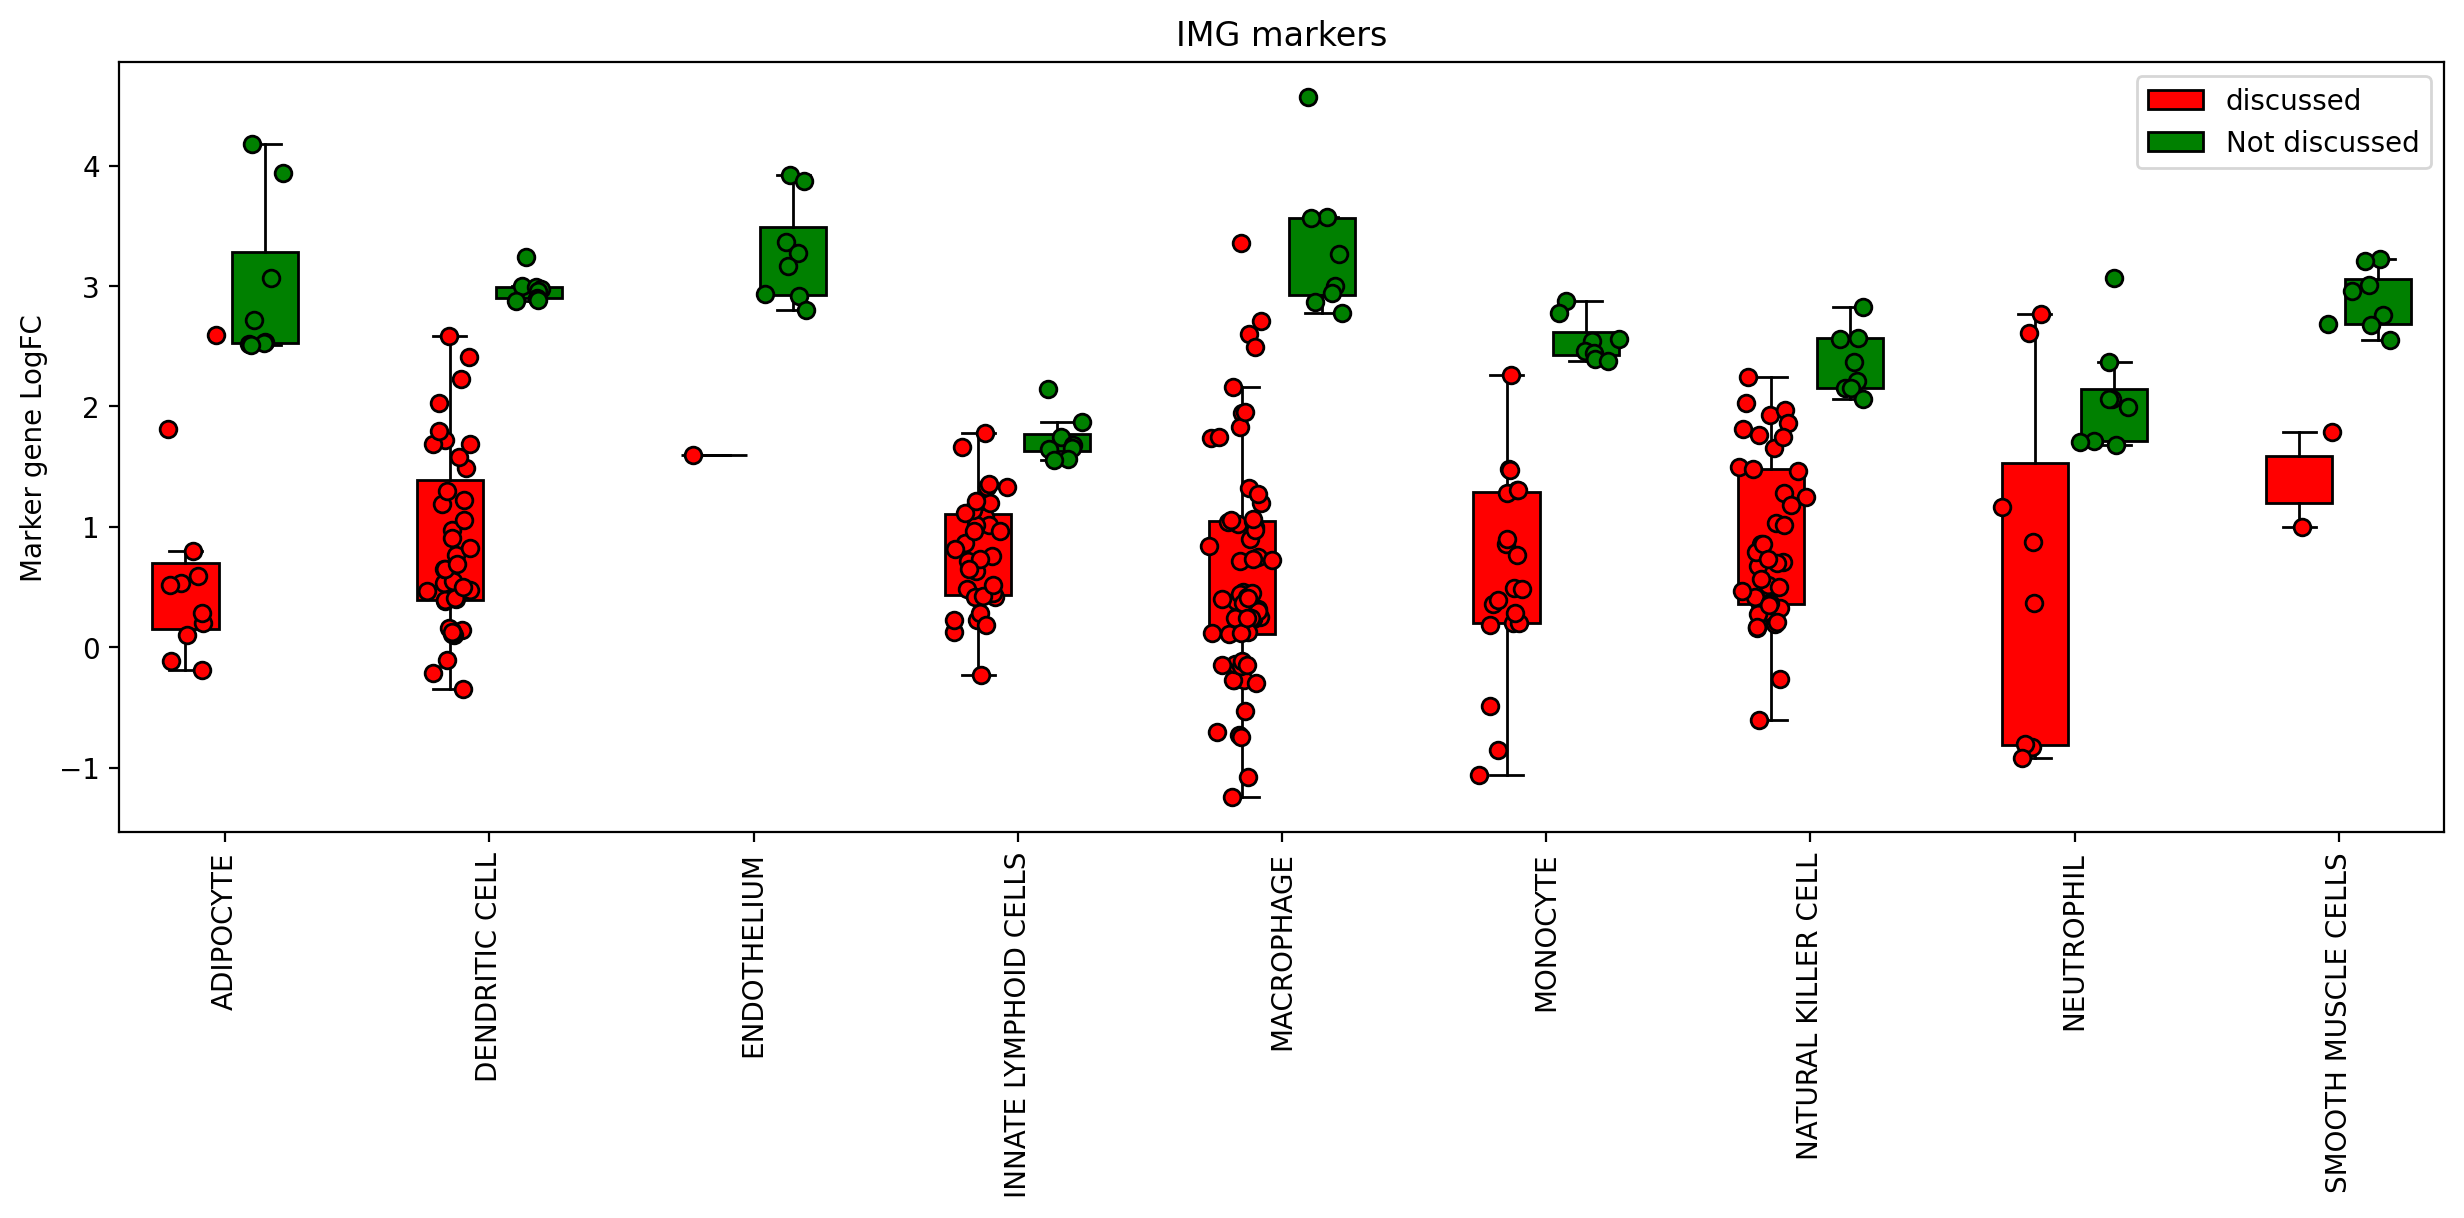

In [199]:
fig, ax = plt.subplots(figsize=(15, 5))

dist_bw = 2
space = 0.3

# Data preparation
labels = v_d_img[v_d_img.apply(lambda x: len(x)>0)].index
x = v_d_img[v_d_img.apply(lambda x: len(x)>0)].values
y = v_n_img[v_n_img.apply(lambda x: len(x)>0)].values

idx = np.arange(len(labels)) * dist_bw

# Boxplots
ax.boxplot(x, positions=idx - space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='red'), label="discussed", showfliers=False)
ax.boxplot(y, positions=idx + space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='green'), label="Not discussed", showfliers=False)

for i, xx, yy in zip(idx, x, y):
    xxx = np.random.normal(i-space, 0.1, size=len(xx))
    yyy = np.random.normal(i+space, 0.1, size=len(yy))
    ax.scatter(xxx, xx, edgecolor="k", facecolor="red", zorder=10)
    ax.scatter(yyy, yy, edgecolor="k", facecolor="green", zorder=10)


# Formatting
ax.set(**{
    "xticks": np.arange(len(labels)) * dist_bw,
    "xticklabels": labels,
    "ylabel": "Marker gene LogFC",
    "title": "IMG markers"
})
# for v in  np.arange(len(labels)) * dist_bw + dist_bw/2:
#     ax.axvline(v, color="lightgrey")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)

# ax.set_ylim(bottom=0)

ax.legend()
plt.show()

# All consistent Cell Types

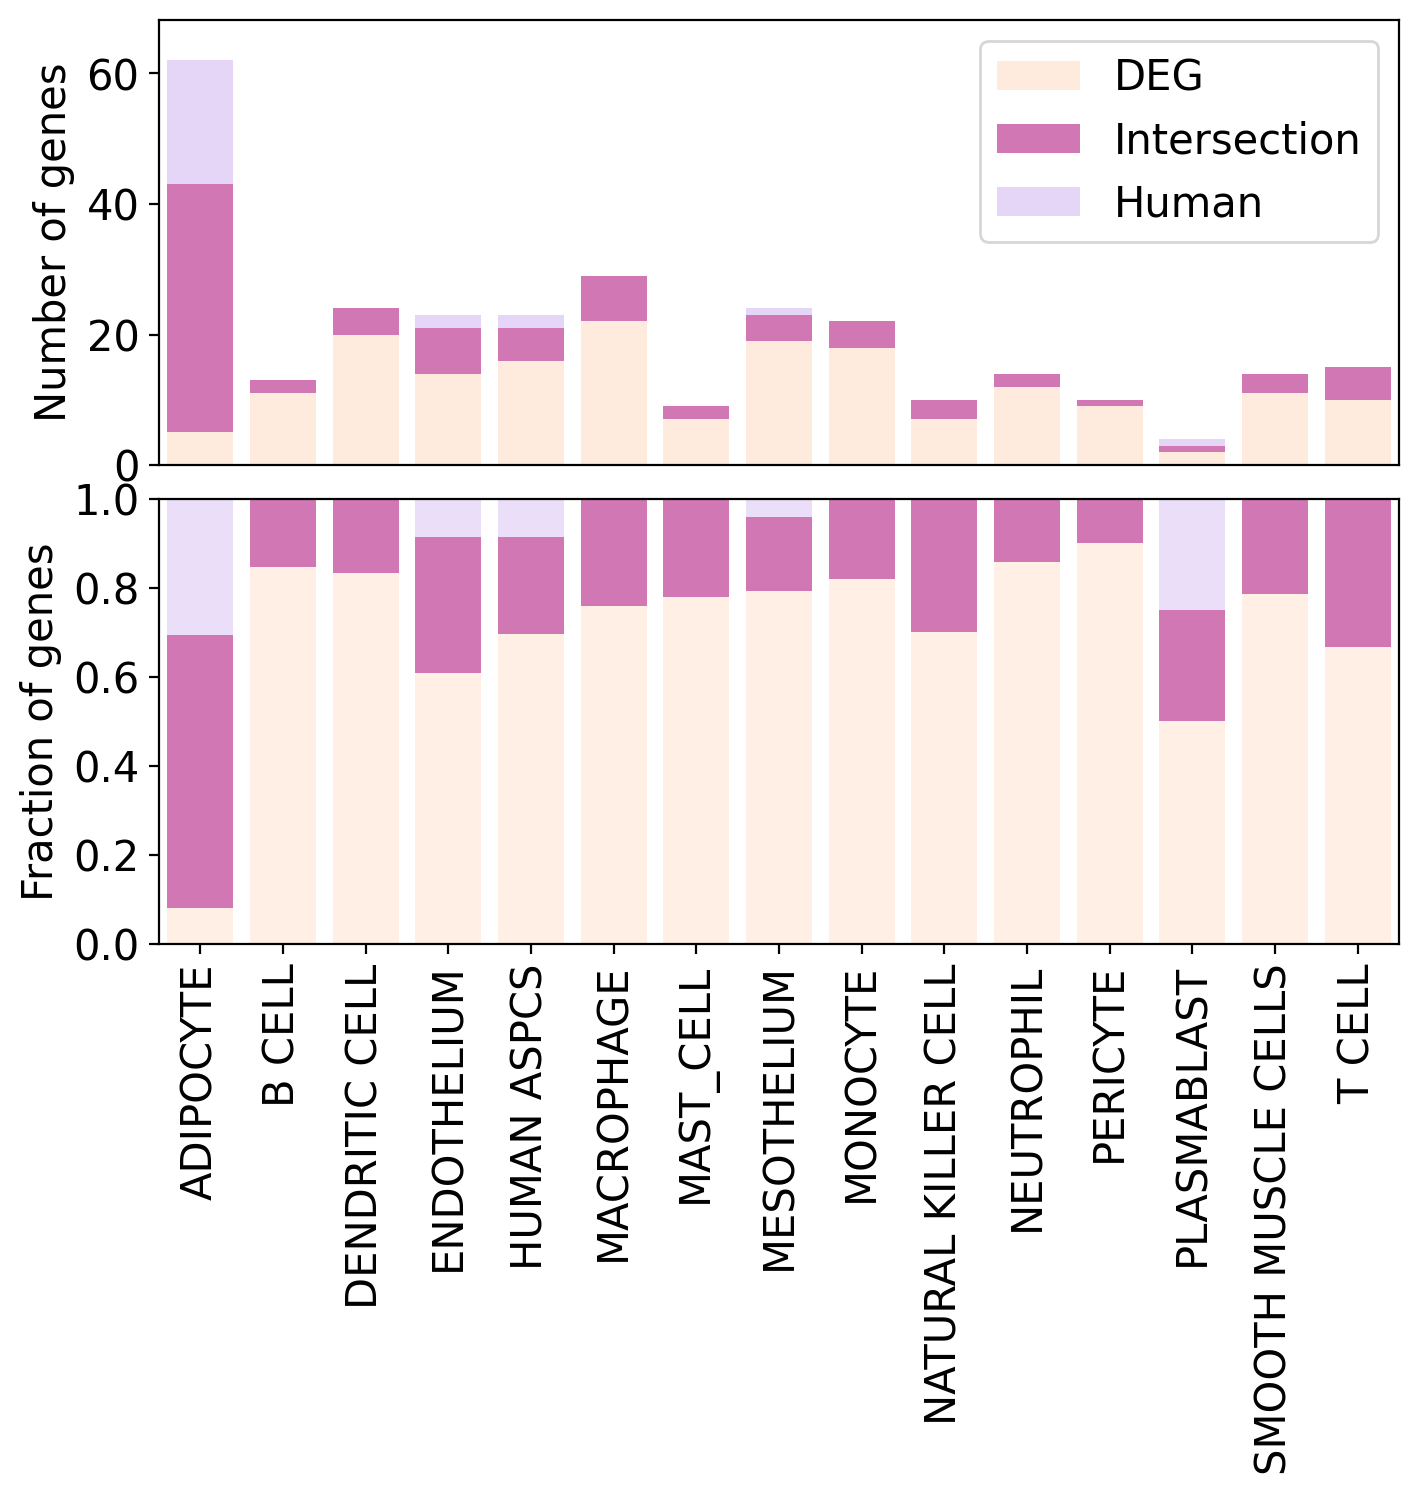

In [83]:
fig, axs = plt.subplots(figsize=(8,6), nrows=2)
fig.subplots_adjust(hspace=0.075, wspace=0.5)
ax = axs[0]
y3 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y1 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.25, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.25, label=f'Human')

ax.set(
    **{
        "ylabel": "Number of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max()),
        "xlim": (-0.5, len(x)-0.5)
    }
)
ax.xaxis.set_visible(False)

# ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend()#bbox_to_anchor=(1,1))

ax = axs[1]
ax.sharex(axs[0])
y3 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y1 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'DEG')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'Human')

ax.set(
    **{
        "ylabel": "Fraction of genes",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1),
        "xlim": (-0.5, len(x)-0.5)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Show the plot
plt.show()
